In [2]:
!pip install muon igraph leidenalg crc32c

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.7/293.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.2/174.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 119.2 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading processed MuData...


/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Loaded data: 34774 cells
ATAC LSI shape: (34774, 50)

Calculating ATAC sequencing depth metrics...
ATAC total counts - Mean: 4231.2, Median: 3220.0
ATAC peaks detected - Mean: 4016.5, Median: 3127.5

Correlation Analysis:
Component    vs Total Counts           vs N Peaks               
             Pearson      Spearman     Pearson      Spearman    
LSI_0       -0.057 (p=4.59e-26)   0.015 (p=5.97e-03)  -0.061 (p=1.07e-29)   0.011 (p=4.40e-02)
LSI_1        0.147 (p=7.61e-168)   0.201 (p=0.00e+00)   0.151 (p=3.54e-176)   0.201 (p=0.00e+00)
LSI_2        0.097 (p=7.68e-73)   0.182 (p=5.94e-258)   0.101 (p=1.68e-79)   0.182 (p=3.33e-256)
LSI_3       -0.105 (p=1.62e-85)  -0.100 (p=1.85e-77)  -0.110 (p=2.50e-94)  -0.099 (p=3.57e-76)
LSI_4       -0.100 (p=1.08e-77)  -0.078 (p=2.46e-48)  -0.104 (p=9.18e-85)  -0.079 (p=1.12e-48)
LSI_5       -0.063 (p=1.74e-31)  -0.124 (p=9.91e-120)  -0.068 (p=9.00e-37)  -0.123 (p=6.37e-118)
LSI_6        0.091 (p=1.82e-64)   0.149 (p=1.62e-172)   0.095 (p=6.65e-7

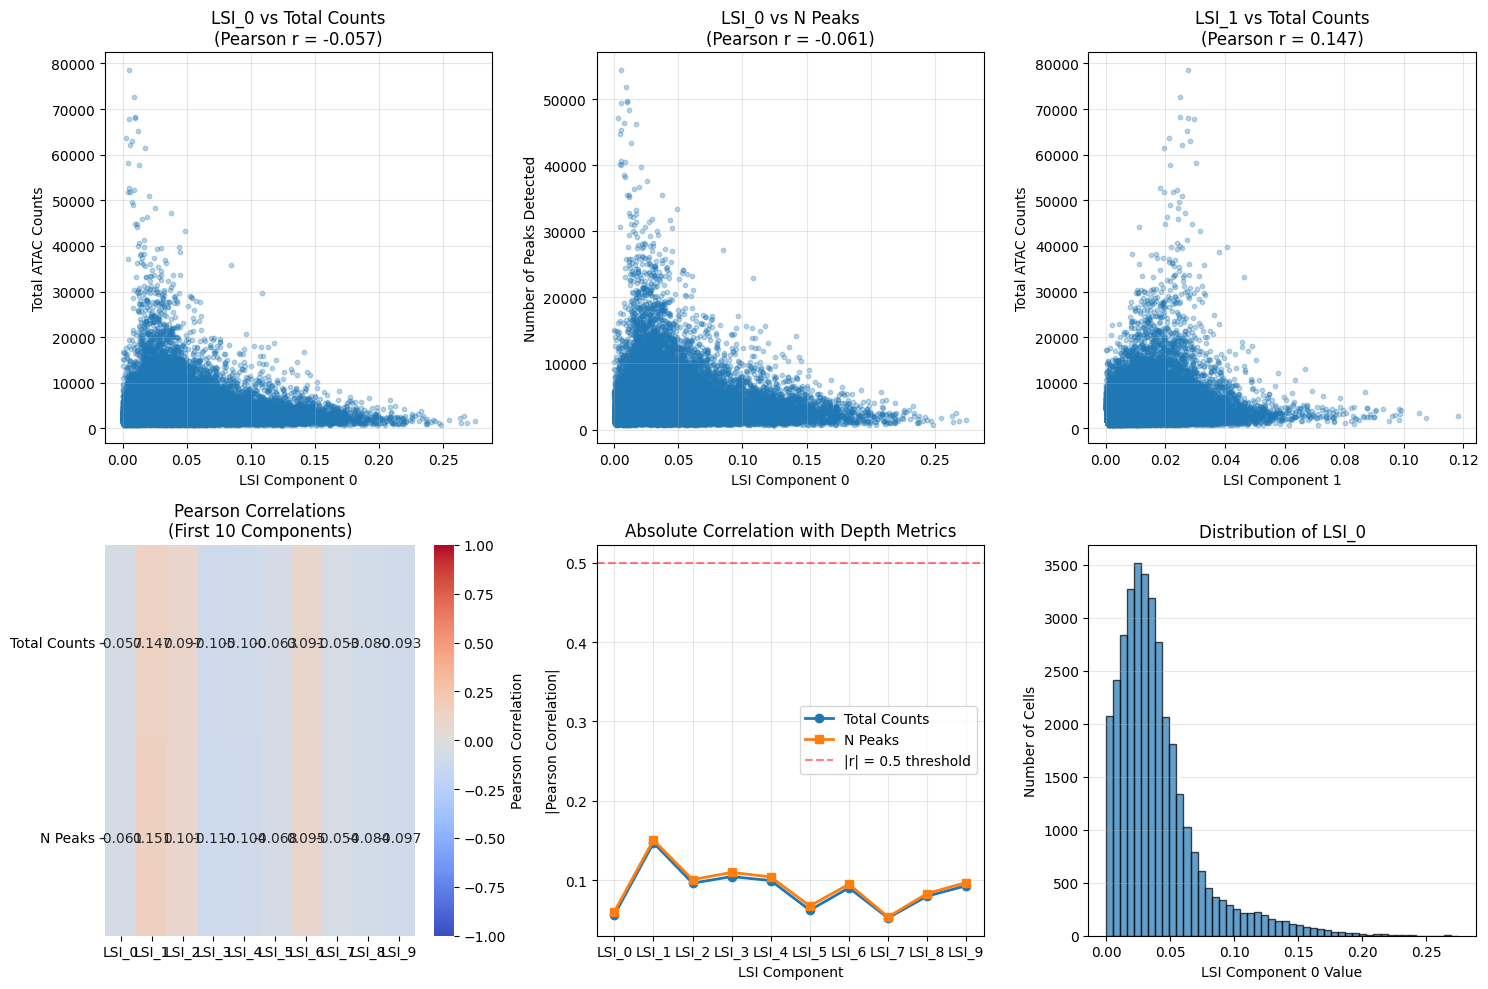

Saved correlations to: LSI_correlations.csv

ANALYSIS COMPLETE


In [5]:
"""
Check if the first LSI/cisTopic component correlates with sequencing depth
Run this after your preprocessing script
"""

import mudata as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Load your processed data
print("Loading processed MuData...")
mdata = md.read_h5mu('/content/drive/MyDrive/Multiome_UMAP_Project/data/processed/GSE140203_SHARE_seq_processed.h5mu')

print(f"Loaded data: {mdata.n_obs} cells")
print(f"ATAC LSI shape: {mdata.obsm['X_atac_lsi'].shape}")

# Calculate sequencing depth metrics for ATAC
print("\nCalculating ATAC sequencing depth metrics...")

# Total counts per cell (sum across all peaks)
atac_total_counts = np.array(mdata.mod['atac'].X.sum(axis=1)).flatten()

# Number of peaks detected per cell (non-zero peaks)
atac_n_peaks = np.array((mdata.mod['atac'].X > 0).sum(axis=1)).flatten()

# Store in obs
mdata.obs['atac_total_counts'] = atac_total_counts
mdata.obs['atac_n_peaks'] = atac_n_peaks

print(f"ATAC total counts - Mean: {atac_total_counts.mean():.1f}, Median: {np.median(atac_total_counts):.1f}")
print(f"ATAC peaks detected - Mean: {atac_n_peaks.mean():.1f}, Median: {np.median(atac_n_peaks):.1f}")

# Extract all LSI components
lsi_components = mdata.obsm['X_atac_lsi']

# Calculate correlations for each LSI component
print("\nCorrelation Analysis:")
print("=" * 70)
print(f"{'Component':<12} {'vs Total Counts':<25} {'vs N Peaks':<25}")
print(f"{'':>12} {'Pearson':<12} {'Spearman':<12} {'Pearson':<12} {'Spearman':<12}")
print("=" * 70)

correlations = []
for i in range(min(10, lsi_components.shape[1])):  # Check first 10 components
    comp = lsi_components[:, i]

    # Correlations with total counts
    pearson_counts, p_pearson_counts = pearsonr(comp, atac_total_counts)
    spearman_counts, p_spearman_counts = spearmanr(comp, atac_total_counts)

    # Correlations with number of peaks
    pearson_peaks, p_pearson_peaks = pearsonr(comp, atac_n_peaks)
    spearman_peaks, p_spearman_peaks = spearmanr(comp, atac_n_peaks)

    correlations.append({
        'component': i,
        'pearson_counts': pearson_counts,
        'spearman_counts': spearman_counts,
        'pearson_peaks': pearson_peaks,
        'spearman_peaks': spearman_peaks
    })

    print(f"LSI_{i:<7} {pearson_counts:>6.3f} (p={p_pearson_counts:.2e})  "
          f"{spearman_counts:>6.3f} (p={p_spearman_counts:.2e})  "
          f"{pearson_peaks:>6.3f} (p={p_pearson_peaks:.2e})  "
          f"{spearman_peaks:>6.3f} (p={p_spearman_peaks:.2e})")

print("=" * 70)

# Highlight the strongest correlation
corr_df = pd.DataFrame(correlations)
abs_corr_df = corr_df[['pearson_counts', 'spearman_counts', 'pearson_peaks', 'spearman_peaks']].abs()
max_corr_idx = abs_corr_df.max(axis=1).idxmax()
max_corr_type = abs_corr_df.loc[max_corr_idx].idxmax()
max_corr_value = corr_df.loc[max_corr_idx, max_corr_type]

print(f"\n🔍 STRONGEST CORRELATION:")
print(f"   Component {max_corr_idx} - {max_corr_type}: {max_corr_value:.3f}")

if abs(corr_df.loc[0, 'pearson_counts']) > 0.5 or abs(corr_df.loc[0, 'spearman_counts']) > 0.5:
    print(f"\n⚠️  WARNING: LSI_0 shows strong correlation with sequencing depth!")
    print(f"   Pearson: {corr_df.loc[0, 'pearson_counts']:.3f}")
    print(f"   Spearman: {corr_df.loc[0, 'spearman_counts']:.3f}")
    print(f"\n   Recommendation: Consider excluding LSI_0 from downstream analysis")
else:
    print(f"\n✅ LSI_0 shows weak correlation with sequencing depth")
    print(f"   Pearson: {corr_df.loc[0, 'pearson_counts']:.3f}")
    print(f"   Spearman: {corr_df.loc[0, 'spearman_counts']:.3f}")
    print(f"\n   This is good - cisTopic may have already handled depth normalization!")

# Create visualizations
print("\nGenerating plots...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: LSI_0 vs Total Counts
ax = axes[0, 0]
ax.scatter(lsi_components[:, 0], atac_total_counts, alpha=0.3, s=10)
ax.set_xlabel('LSI Component 0')
ax.set_ylabel('Total ATAC Counts')
ax.set_title(f'LSI_0 vs Total Counts\n(Pearson r = {corr_df.loc[0, "pearson_counts"]:.3f})')
ax.grid(True, alpha=0.3)

# Plot 2: LSI_0 vs N Peaks
ax = axes[0, 1]
ax.scatter(lsi_components[:, 0], atac_n_peaks, alpha=0.3, s=10)
ax.set_xlabel('LSI Component 0')
ax.set_ylabel('Number of Peaks Detected')
ax.set_title(f'LSI_0 vs N Peaks\n(Pearson r = {corr_df.loc[0, "pearson_peaks"]:.3f})')
ax.grid(True, alpha=0.3)

# Plot 3: LSI_1 vs Total Counts (for comparison)
ax = axes[0, 2]
ax.scatter(lsi_components[:, 1], atac_total_counts, alpha=0.3, s=10)
ax.set_xlabel('LSI Component 1')
ax.set_ylabel('Total ATAC Counts')
ax.set_title(f'LSI_1 vs Total Counts\n(Pearson r = {corr_df.loc[1, "pearson_counts"]:.3f})')
ax.grid(True, alpha=0.3)

# Plot 4: Correlation heatmap
ax = axes[1, 0]
corr_matrix = corr_df[['pearson_counts', 'pearson_peaks']].head(10).T
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_xticklabels([f'LSI_{i}' for i in range(10)])
ax.set_yticklabels(['Total Counts', 'N Peaks'], rotation=0)
ax.set_title('Pearson Correlations\n(First 10 Components)')

# Plot 5: Absolute correlation by component
ax = axes[1, 1]
ax.plot(range(10), abs_corr_df['pearson_counts'].head(10), 'o-', label='Total Counts', linewidth=2)
ax.plot(range(10), abs_corr_df['pearson_peaks'].head(10), 's-', label='N Peaks', linewidth=2)
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='|r| = 0.5 threshold')
ax.set_xlabel('LSI Component')
ax.set_ylabel('|Pearson Correlation|')
ax.set_title('Absolute Correlation with Depth Metrics')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(10))
ax.set_xticklabels([f'LSI_{i}' for i in range(10)])

# Plot 6: Distribution of LSI_0
ax = axes[1, 2]
ax.hist(lsi_components[:, 0], bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('LSI Component 0 Value')
ax.set_ylabel('Number of Cells')
ax.set_title('Distribution of LSI_0')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Multiome_UMAP_Project/data/processed/LSI_depth_correlation_analysis.png',
            dpi=300, bbox_inches='tight')
print("Saved plot to: LSI_depth_correlation_analysis.png")

plt.show()

# Save correlation results
corr_df.to_csv('/content/drive/MyDrive/Multiome_UMAP_Project/data/processed/LSI_correlations.csv',
               index=False)
print("Saved correlations to: LSI_correlations.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)